# Exploratory Data Analysis — BPI Challenge 2017

> **SPI Time Series** · Notebook `01` · Understand the data before modelling
> **Full dataset** — Runs on the complete BPI Challenge 2017 log

This notebook performs **exploratory data analysis (EDA)** on the raw XES event log
from the BPI Challenge 2017 dataset. It focuses solely on understanding the
structure and content of the data — no pipeline logic, feature extraction, or
preprocessing is involved.

We will cover:
- **Dataset loading** via the project's `Dataset` class.
- **Basic counts**: total events and unique cases.
- **Case length distribution**: how many events per process instance.
- **Activity frequency**: which activities dominate the log.
- **Temporal patterns**: throughput over time and inter-arrival times.

## 1. Import Required Libraries

We import the `Dataset` class (which handles downloading and caching the XES log)
along with `pandas`, `matplotlib`, and `pm4py` for analysis and visualization.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pm4py

from spi_time_series.data.dataset import Dataset

# Configure matplotlib for inline plotting
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

## 2. Initialize the Dataset and Load the Event Log

The `Dataset` class downloads the BPI Challenge 2017 XES file on first access and
caches it locally. The `dataset.log` property returns a Pandas DataFrame with one
row per event. Key columns include:

- `case:concept:name` — the case (process instance) identifier.
- `concept:name` — the activity name.
- `time:timestamp` — the event timestamp.

In [2]:
# Initialize the dataset — this will download the XES file on first run.
dataset = Dataset()

# Load the raw event log as a Pandas DataFrame.
log = dataset.log

# Preview the first few rows and column types.
print(f"Shape: {log.shape[0]:,} events × {log.shape[1]} columns\n")
log.head()

c:\Users\roman\Documents\Uni\Aachen\Semester_3\SoftwarePraktikum\spi-time-series\.venv\Lib\site-packages\pm4py\utils.py:1005: UserWarning: In the current version, the import/export operation uses `r4pm` by default for importing/exporting files faster.
  warnings.warn(


Shape: 1,202,267 events × 19 columns



,concept:name,case:ApplicationType,OfferedAmount,MonthlyCost,org:resource,NumberOfTerms,CreditScore,case:concept:name,EventID,EventOrigin,FirstWithdrawalAmount,Selected,OfferID,Action,time:timestamp,case:LoanGoal,Accepted,lifecycle:transition,case:RequestedAmount
0,A_Create Application,New credit,NaN,NaN,User_1,NaN,NaN,Application_652823628,Application_652823628,Application,NaN,None,None,Created,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,None,complete,20000.0
1,A_Submitted,New credit,NaN,NaN,User_1,NaN,NaN,Application_652823628,ApplState_1582051990,Application,NaN,None,None,statechange,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,None,complete,20000.0
2,W_Handle leads,New credit,NaN,NaN,User_1,NaN,NaN,Application_652823628,Workitem_1298499574,Workflow,NaN,None,None,Created,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,None,schedule,20000.0
3,W_Handle leads,New credit,NaN,NaN,User_1,NaN,NaN,Application_652823628,Workitem_1673366067,Workflow,NaN,None,None,Deleted,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,None,withdraw,20000.0
4,W_Complete application,New credit,NaN,NaN,User_1,NaN,NaN,Application_652823628,Workitem_1493664571,Workflow,NaN,None,None,Created,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,None,schedule,20000.0


## 3. Descriptive Statistics: Total Events and Unique Cases

These basic counts give us a quick sense of the dataset's scale:
- **Total events** tells us how many individual log entries we have.
- **Unique cases** tells us how many distinct process instances (loan applications) are recorded.

In [3]:
total_events = len(log)
unique_cases = log["case:concept:name"].nunique()

print(f"Total events      : {total_events:,}")
print(f"Unique cases      : {unique_cases:,}")
print(f"Avg events / case : {total_events / unique_cases:.1f}")

Total events      : 1,202,267
Unique cases      : 31,509
Avg events / case : 38.2


## 4. Distribution of Case Lengths

The **case length** is the number of events in a single process instance.
The histogram below reveals:
- How many events a typical case contains.
- Whether there are very short or very long-running outliers.
- The overall shape (skew, multi-modality) of process execution lengths.

count    31509.0
mean        38.2
std         16.7
min         10.0
25%         25.0
50%         35.0
75%         47.0
max        180.0


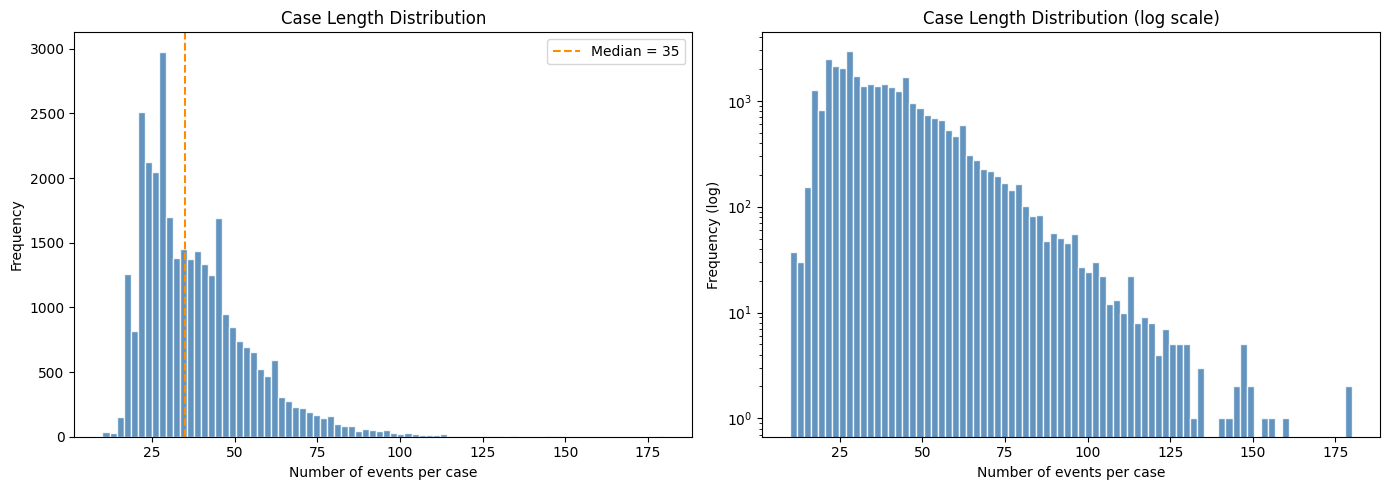

In [4]:
# Compute the number of events per case.
case_lengths = log.groupby("case:concept:name").size()

# Print summary statistics.
print(case_lengths.describe().round(1).to_string())

# Plot the histogram of case lengths.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear-scale histogram
ax1.hist(
    case_lengths, bins=80, color="steelblue", edgecolor="white", alpha=0.85
)
ax1.set_title("Case Length Distribution")
ax1.set_xlabel("Number of events per case")
ax1.set_ylabel("Frequency")
ax1.axvline(
    case_lengths.median(),
    color="darkorange",
    linestyle="--",
    label=f"Median = {case_lengths.median():.0f}",
)
ax1.legend()

# Log-scale histogram (better reveals the tail)
ax2.hist(
    case_lengths, bins=80, color="steelblue", edgecolor="white", alpha=0.85
)
ax2.set_yscale("log")
ax2.set_title("Case Length Distribution (log scale)")
ax2.set_xlabel("Number of events per case")
ax2.set_ylabel("Frequency (log)")

fig.tight_layout()
plt.show()

## 6. Full Activity Frequency Distribution

Beyond the top 10, let's see **every activity** ranked by frequency.
This reveals the long tail of rare activities and the overall concentration
of the process around a few core steps.

Total distinct activities: 26

                             Count      %  Cumul. %
concept:name                                       
W_Validate application      209496  17.43     17.43
W_Call after offers         191092  15.89     33.32
W_Call incomplete files     168529  14.02     47.34
W_Complete application      148900  12.38     59.72
W_Handle leads               47264   3.93     63.65
O_Create Offer               42995   3.58     67.23
O_Created                    42995   3.58     70.81
O_Sent (mail and online)     39707   3.30     74.11
A_Validating                 38816   3.23     77.34
A_Accepted                   31509   2.62     79.96
A_Create Application         31509   2.62     82.58
A_Concept                    31509   2.62     85.20
A_Complete                   31362   2.61     87.81
O_Returned                   23305   1.94     89.75
A_Incomplete                 23055   1.92     91.67
O_Cancelled                  20898   1.74     93.41
A_Submitted                  2042

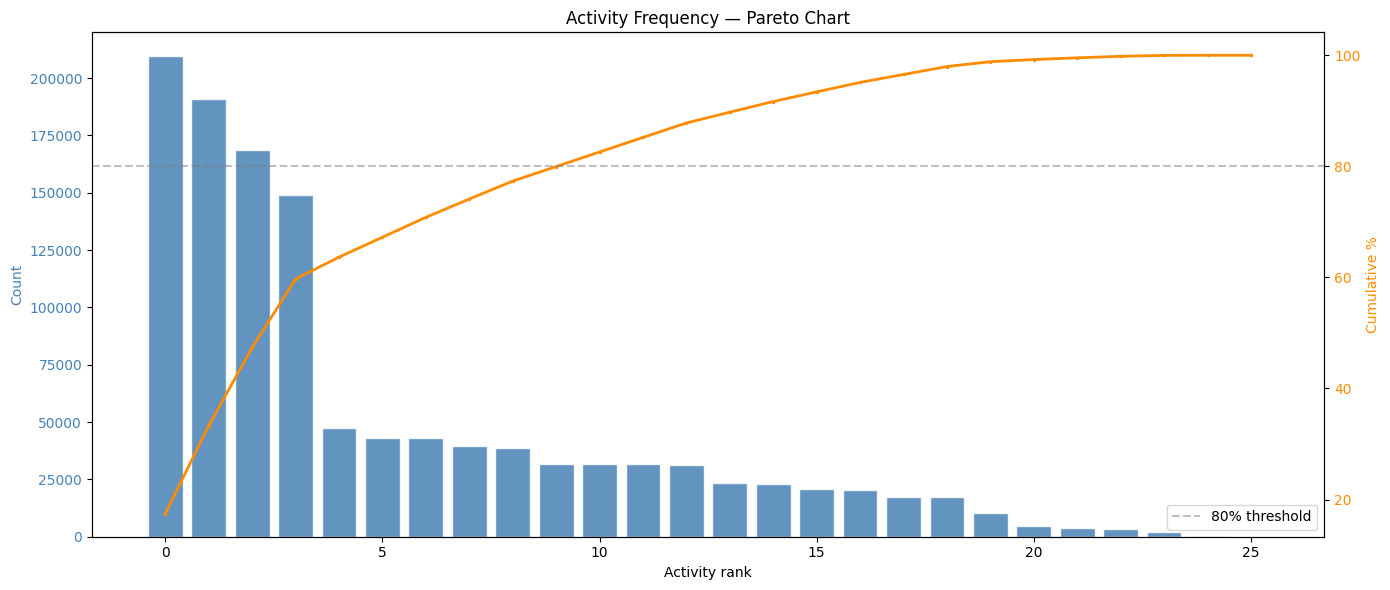

In [5]:
# Full activity ranking with cumulative percentage (Pareto-style).
all_activities = log["concept:name"].value_counts()
pct = (all_activities / len(log) * 100).round(2)
cum_pct = pct.cumsum()

full_summary = pd.DataFrame(
    {
        "Count": all_activities,
        "%": pct,
        "Cumul. %": cum_pct,
    }
)
print(f"Total distinct activities: {len(all_activities)}\n")
print(full_summary.to_string())

# Pareto chart: bar chart + cumulative line.
fig, ax1 = plt.subplots(figsize=(14, 6))

colors = ["steelblue"] * len(all_activities)
ax1.bar(
    range(len(all_activities)),
    all_activities.values,
    color=colors,
    edgecolor="white",
    alpha=0.85,
)
ax1.set_xlabel("Activity rank")
ax1.set_ylabel("Count", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(
    range(len(all_activities)),
    cum_pct.values,
    color="darkorange",
    linewidth=2,
    marker=".",
    markersize=3,
)
ax2.set_ylabel("Cumulative %", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.axhline(80, color="gray", linestyle="--", alpha=0.5, label="80% threshold")
ax2.legend(loc="lower right")

ax1.set_title("Activity Frequency — Pareto Chart")
fig.tight_layout()
plt.show()

## 7. Temporal Patterns — Events Over Time

Understanding **when** events occur reveals seasonal trends, spikes, and lulls.
We'll resample the event stream by month and by day-of-week to spot patterns.

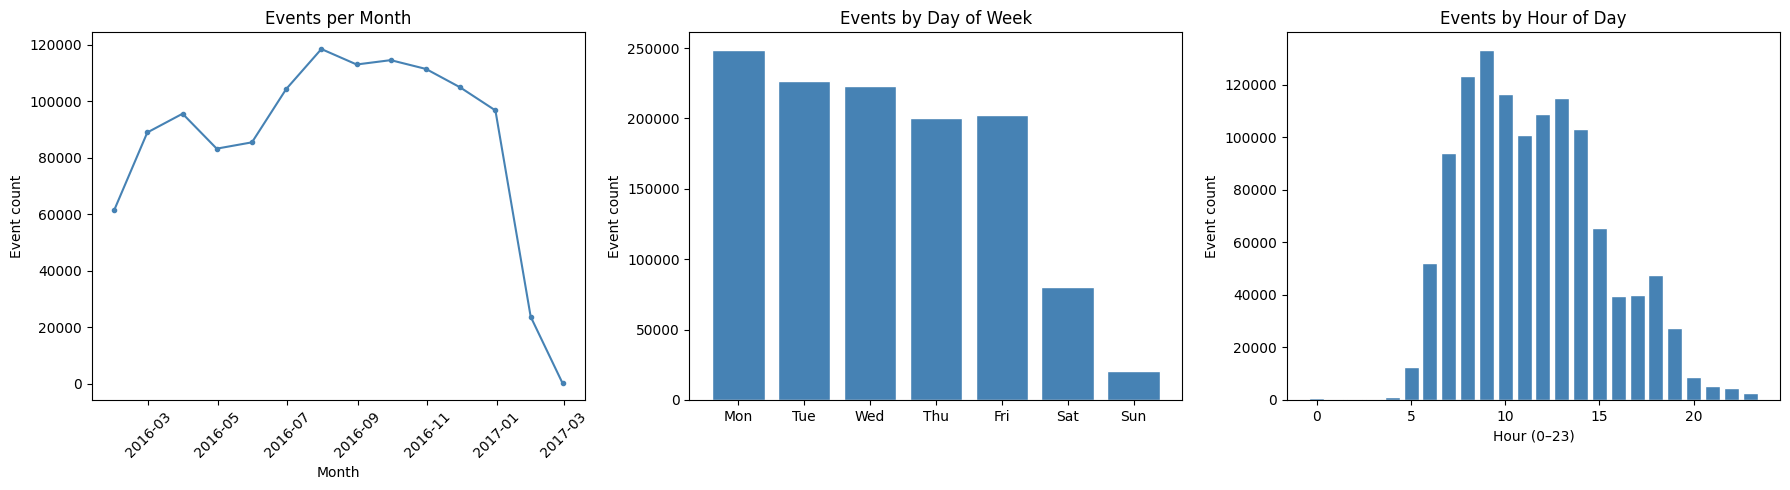

In [6]:
# ── Events per month ──────────────────────────────────────────
monthly = log.set_index("time:timestamp").resample("ME").size()

# ── Events per day of week ────────────────────────────────────
dow = log["time:timestamp"].dt.dayofweek.value_counts().sort_index()

# ── Events per hour ───────────────────────────────────────────
hour = log["time:timestamp"].dt.hour.value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Monthly trend
axes[0].plot(
    monthly.index, monthly.values, color="steelblue", marker="o", markersize=3
)
axes[0].set_title("Events per Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Event count")
axes[0].tick_params(axis="x", rotation=45)

# Day of week
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[1].bar(dow_labels, dow.values, color="steelblue", edgecolor="white")
axes[1].set_title("Events by Day of Week")
axes[1].set_ylabel("Event count")

# Hour of day
axes[2].bar(hour.index, hour.values, color="steelblue", edgecolor="white")
axes[2].set_title("Events by Hour of Day")
axes[2].set_xlabel("Hour (0–23)")
axes[2].set_ylabel("Event count")

fig.tight_layout()
plt.show()

## 8. Case Duration Analysis

**Case duration** is the time elapsed between the first and last event of a case.
This shows how long a typical loan application takes end-to-end, and reveals
outliers that may indicate stalled or fast-tracked cases.

Case duration (hours):
count    31509.0
mean       525.6
std        316.1
min          0.1
25%        271.8
50%        458.1
75%        755.9
max       6865.7

Case duration (days):
count    31509.0
mean        21.9
std         13.2
min          0.0
25%         11.3
50%         19.1
75%         31.5
max        286.1


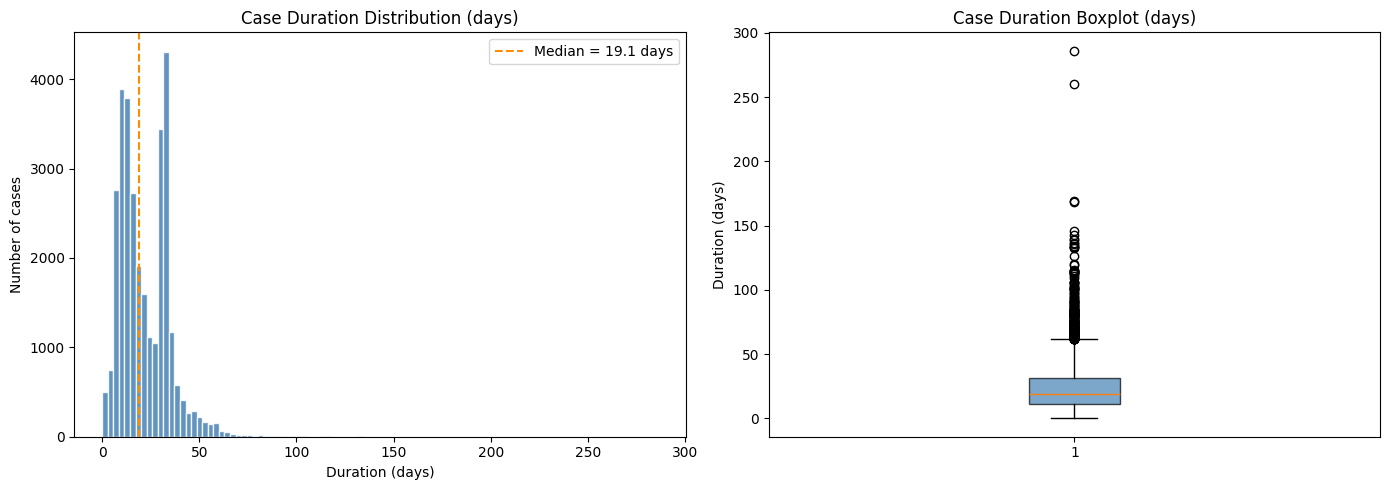

In [7]:
# Compute case start and end times.
case_times = log.groupby("case:concept:name")["time:timestamp"].agg(
    ["min", "max"]
)
case_durations = (
    case_times["max"] - case_times["min"]
).dt.total_seconds() / 3600  # hours

# Print summary (in hours, then days).
print("Case duration (hours):")
print(case_durations.describe().round(1).to_string())
print(f"\nCase duration (days):")
print((case_durations / 24).describe().round(1).to_string())

# Histogram + boxplot.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(
    case_durations / 24,
    bins=100,
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)
ax1.set_title("Case Duration Distribution (days)")
ax1.set_xlabel("Duration (days)")
ax1.set_ylabel("Number of cases")
ax1.axvline(
    case_durations.median() / 24,
    color="darkorange",
    linestyle="--",
    label=f"Median = {case_durations.median() / 24:.1f} days",
)
ax1.legend()

ax2.boxplot(
    case_durations / 24,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.7),
)
ax2.set_title("Case Duration Boxplot (days)")
ax2.set_ylabel("Duration (days)")

fig.tight_layout()
plt.show()

## 9. Process Variant Analysis

A **variant** is a unique sequence of activities that a case follows (ignoring
timestamps). Analyzing variants shows how many distinct paths exist and how
concentrated the process is — a few variants typically dominate.

Total unique variants: 15,930
Top 10 variants cover 15.3% of all cases

   1. [ 1056 cases,   3.4%] A_Create Application,A_Submitted,W_Handle leads,W_Handle leads,W_Complete application,A_Concept,W...
   2. [ 1021 cases,   3.2%] A_Create Application,W_Complete application,W_Complete application,A_Concept,A_Accepted,O_Create ...
   3. [  734 cases,   2.3%] A_Create Application,A_Submitted,W_Handle leads,W_Handle leads,W_Complete application,A_Concept,W...
   4. [  451 cases,   1.4%] A_Create Application,A_Submitted,W_Handle leads,W_Handle leads,W_Complete application,A_Concept,W...
   5. [  332 cases,   1.1%] A_Create Application,A_Submitted,W_Handle leads,W_Handle leads,W_Complete application,A_Concept,A...
   6. [  298 cases,   0.9%] A_Create Application,A_Submitted,W_Handle leads,W_Handle leads,W_Complete application,A_Concept,W...
   7. [  278 cases,   0.9%] A_Create Application,W_Complete application,W_Complete application,A_Concept,A_Accepted,O_Create ...
   8. [  244 cases,   0.8

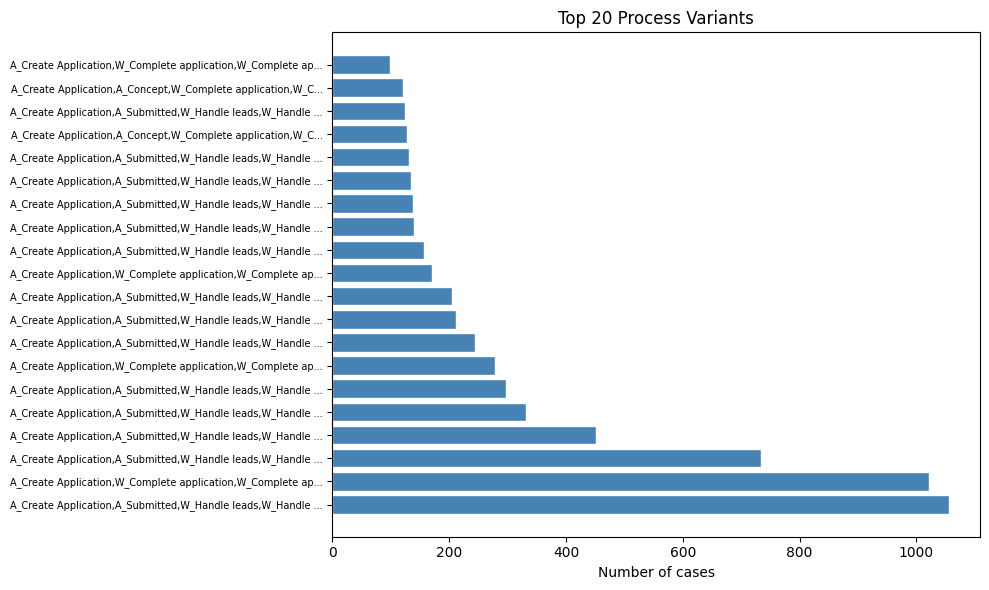

In [8]:
# Build variant strings (comma-separated activity sequences).
variants = log.groupby("case:concept:name")["concept:name"].agg(
    lambda x: ",".join(x)
)
variant_counts = variants.value_counts()

print(f"Total unique variants: {len(variant_counts):,}")
print(
    f"Top 10 variants cover {variant_counts.head(10).sum() / unique_cases * 100:.1f}% of all cases\n"
)

# Show top 15 variants.
for i, (variant, count) in enumerate(variant_counts.head(15).items(), 1):
    # Truncate long variant strings for readability.
    label = variant if len(variant) <= 100 else variant[:97] + "..."
    print(
        f"  {i:2d}. [{count:5d} cases, {count / unique_cases * 100:5.1f}%] {label}"
    )

# Plot top N variants as a horizontal bar chart.
top_n = 20
top_variants = variant_counts.head(top_n)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    range(top_n),
    top_variants.values[::-1],
    color="steelblue",
    edgecolor="white",
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(
    [v if len(v) <= 60 else v[:57] + "..." for v in top_variants.index[::-1]],
    fontsize=7,
)
ax.set_xlabel("Number of cases")
ax.set_title(f"Top {top_n} Process Variants")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## 10. Start & End Activities

Which activities initiate a case? Which ones close it? This tells us about
the entry and exit points of the process.

concept:name
W_Validate application        12662
W_Call after offers            9457
W_Call incomplete files        4676
O_Cancelled                    4436
W_Complete application          144
W_Assess potential fraud        102
O_Sent (mail and online)         15
O_Sent (online only)              8
W_Shortened completion            5
W_Personal Loan collection        2
Name: count, dtype: int64


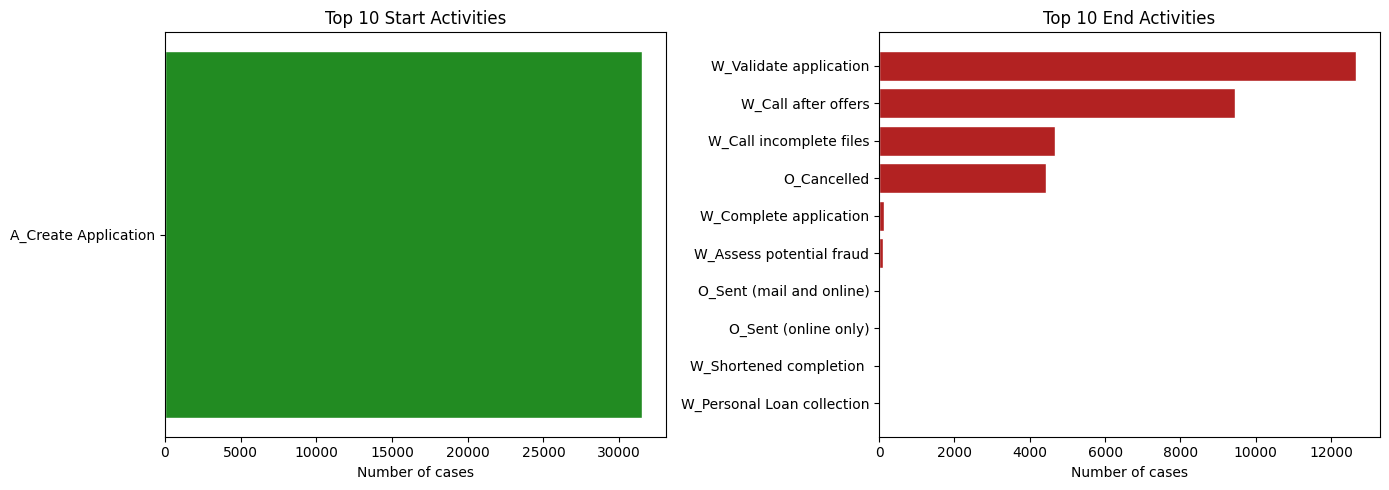

In [9]:
# First and last event per case (by timestamp).
sorted_log = log.sort_values(["case:concept:name", "time:timestamp"])
first_events = sorted_log.groupby("case:concept:name").first()["concept:name"]
last_events = sorted_log.groupby("case:concept:name").last()["concept:name"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

start_counts = first_events.value_counts().head(10)
ax1.barh(
    start_counts.index[::-1],
    start_counts.values[::-1],
    color="forestgreen",
    edgecolor="white",
)
ax1.set_title("Top 10 Start Activities")
ax1.set_xlabel("Number of cases")

end_counts = last_events.value_counts().head(10)
ax2.barh(
    end_counts.index[::-1],
    end_counts.values[::-1],
    color="firebrick",
    edgecolor="white",
)
ax2.set_title("Top 10 End Activities")
ax2.set_xlabel("Number of cases")

print(end_counts)

fig.tight_layout()
plt.show()

## 11. Day-of-Week × Hour Heatmap

A heatmap of **hour vs. day of week** reveals when the process is most active.
Dark spots indicate peak working hours; blank areas show off-hours.

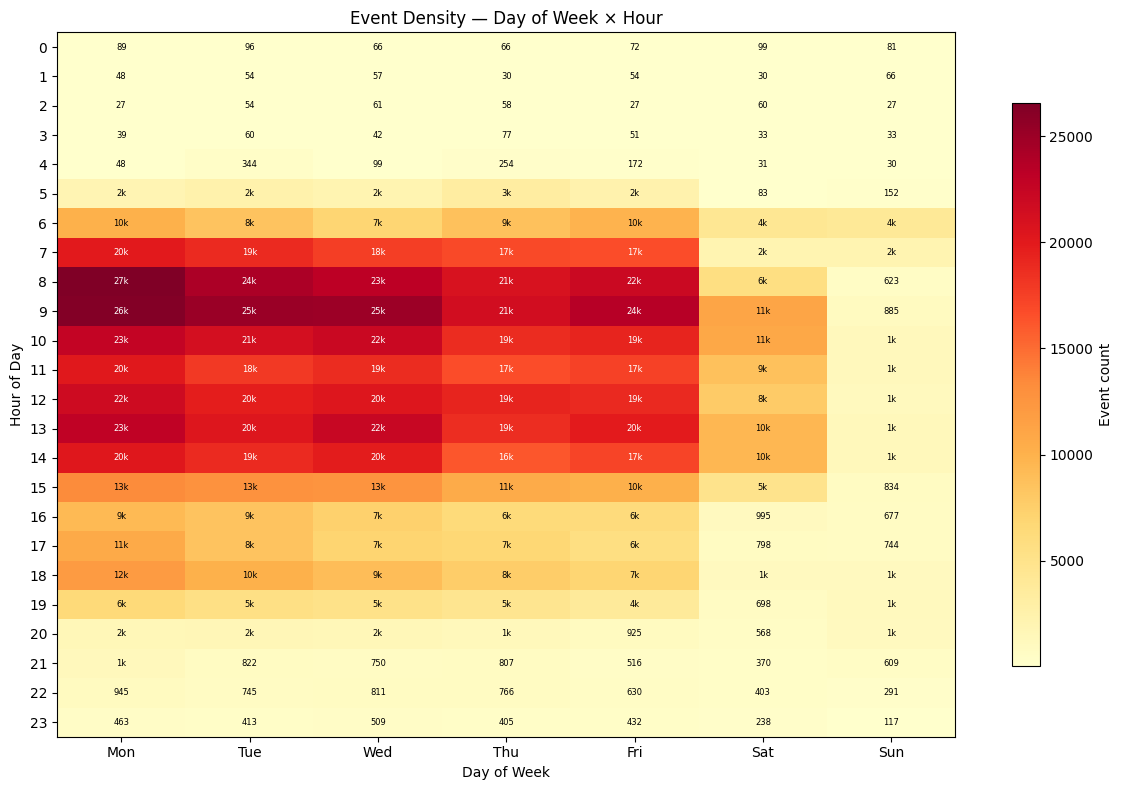

In [10]:
# Create a pivot table of hour × day-of-week.
log_temp = log.copy()
log_temp["hour"] = log_temp["time:timestamp"].dt.hour
log_temp["dow"] = log_temp["time:timestamp"].dt.dayofweek
heatmap = log_temp.pivot_table(
    index="hour", columns="dow", aggfunc="size", fill_value=0
)
heatmap.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heatmap.values, aspect="auto", cmap="YlOrRd", origin="upper")

ax.set_xticks(range(7))
ax.set_xticklabels(heatmap.columns)
ax.set_yticks(range(24))
ax.set_yticklabels(range(24))
ax.set_xlabel("Day of Week")
ax.set_ylabel("Hour of Day")
ax.set_title("Event Density — Day of Week × Hour")

# Annotate each cell with its count (abbreviated).
for i in range(24):
    for j in range(7):
        val = heatmap.values[i, j]
        if val > 0:
            text = f"{val / 1000:.0f}k" if val >= 1000 else str(val)
            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=6,
                color="white" if val > heatmap.values.max() * 0.6 else "black",
            )

fig.colorbar(im, ax=ax, shrink=0.8, label="Event count")
fig.tight_layout()
plt.show()

## 12. Lifecycle Transitions

Events in this log have a `lifecycle:transition` field (e.g. *start*, *complete*,
*schedule*). Understanding the breakdown of transitions helps assess event
granularity and whether we need to filter to a specific lifecycle state.

Lifecycle transitions:
  complete                475,306  ( 39.5%)
  suspend                 215,402  ( 17.9%)
  schedule                149,104  ( 12.4%)
  start                   128,227  ( 10.7%)
  resume                  127,160  ( 10.6%)
  ate_abort                85,224  (  7.1%)
  withdraw                 21,844  (  1.8%)


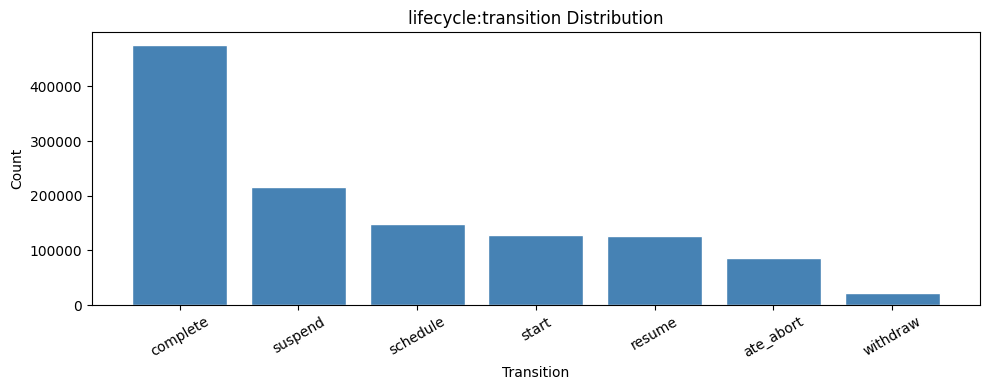

In [11]:
transitions = log["lifecycle:transition"].value_counts()
print("Lifecycle transitions:")
for t, c in transitions.items():
    print(f"  {t:20s} {c:>10,}  ({c / len(log) * 100:5.1f}%)")

# Bar chart.
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    transitions.index, transitions.values, color="steelblue", edgecolor="white"
)
ax.set_title("lifecycle:transition Distribution")
ax.set_ylabel("Count")
ax.set_xlabel("Transition")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

## 13. Data Quality & Column Overview

Check for missing values, duplicate events, and understand what data we have
across all 19 columns. This helps identify any cleaning steps needed later.

Column overview & missing values:

                                     Dtype  Missing  Missing %  Unique Values
concept:name                        object        0       0.00             26
case:ApplicationType                object        0       0.00              2
OfferedAmount                      float64  1159272      96.42            663
MonthlyCost                        float64  1159272      96.42           5816
org:resource                        object        0       0.00            149
NumberOfTerms                      float64  1159272      96.42            147
CreditScore                        float64  1159272      96.42            520
case:concept:name                   object        0       0.00          31509
EventID                             object        0       0.00        1202267
EventOrigin                         object        0       0.00              3
FirstWithdrawalAmount              float64  1159272      96.42           5930
Selected                     

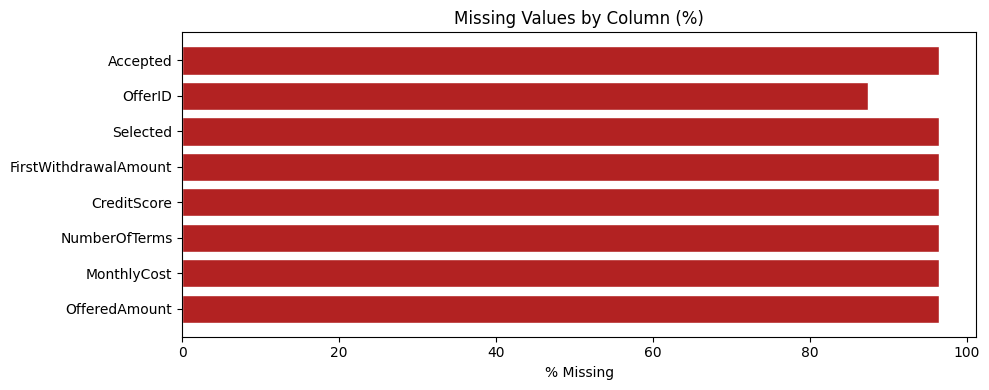

In [12]:
# ── Missing values per column ─────────────────────────────────
missing = log.isnull().sum()
missing_pct = (missing / len(log) * 100).round(2)
quality = pd.DataFrame(
    {
        "Dtype": log.dtypes.astype(str),
        "Missing": missing,
        "Missing %": missing_pct,
        "Unique Values": log.nunique(),
    }
)
print("Column overview & missing values:\n")
print(quality.to_string())

# ── Duplicate rows ────────────────────────────────────────────
dup_rows = log.duplicated().sum()
print(f"\nDuplicate rows: {dup_rows:,}")

# ── Date range ─────────────────────────────────────────────────
print(
    f"Date range  : {log['time:timestamp'].min()}  →  {log['time:timestamp'].max()}"
)

# ── Visualize missing values ───────────────────────────────────
cols_with_missing = missing[missing > 0]
if len(cols_with_missing) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(
        cols_with_missing.index,
        cols_with_missing.values / len(log) * 100,
        color="firebrick",
        edgecolor="white",
    )
    ax.set_title("Missing Values by Column (%)")
    ax.set_xlabel("% Missing")
    fig.tight_layout()
    plt.show()
else:
    print("No missing values found in any column.")

## 14. Case arrival and closure rate

See at what rate cases are opened and closed over time

c:\Users\roman\Documents\Uni\Aachen\Semester_3\SoftwarePraktikum\spi-time-series\.venv\Lib\site-packages\matplotlib\dates.py:449: UserWarning: no explicit representation of timezones available for np.datetime64
  d = d.astype('datetime64[us]')


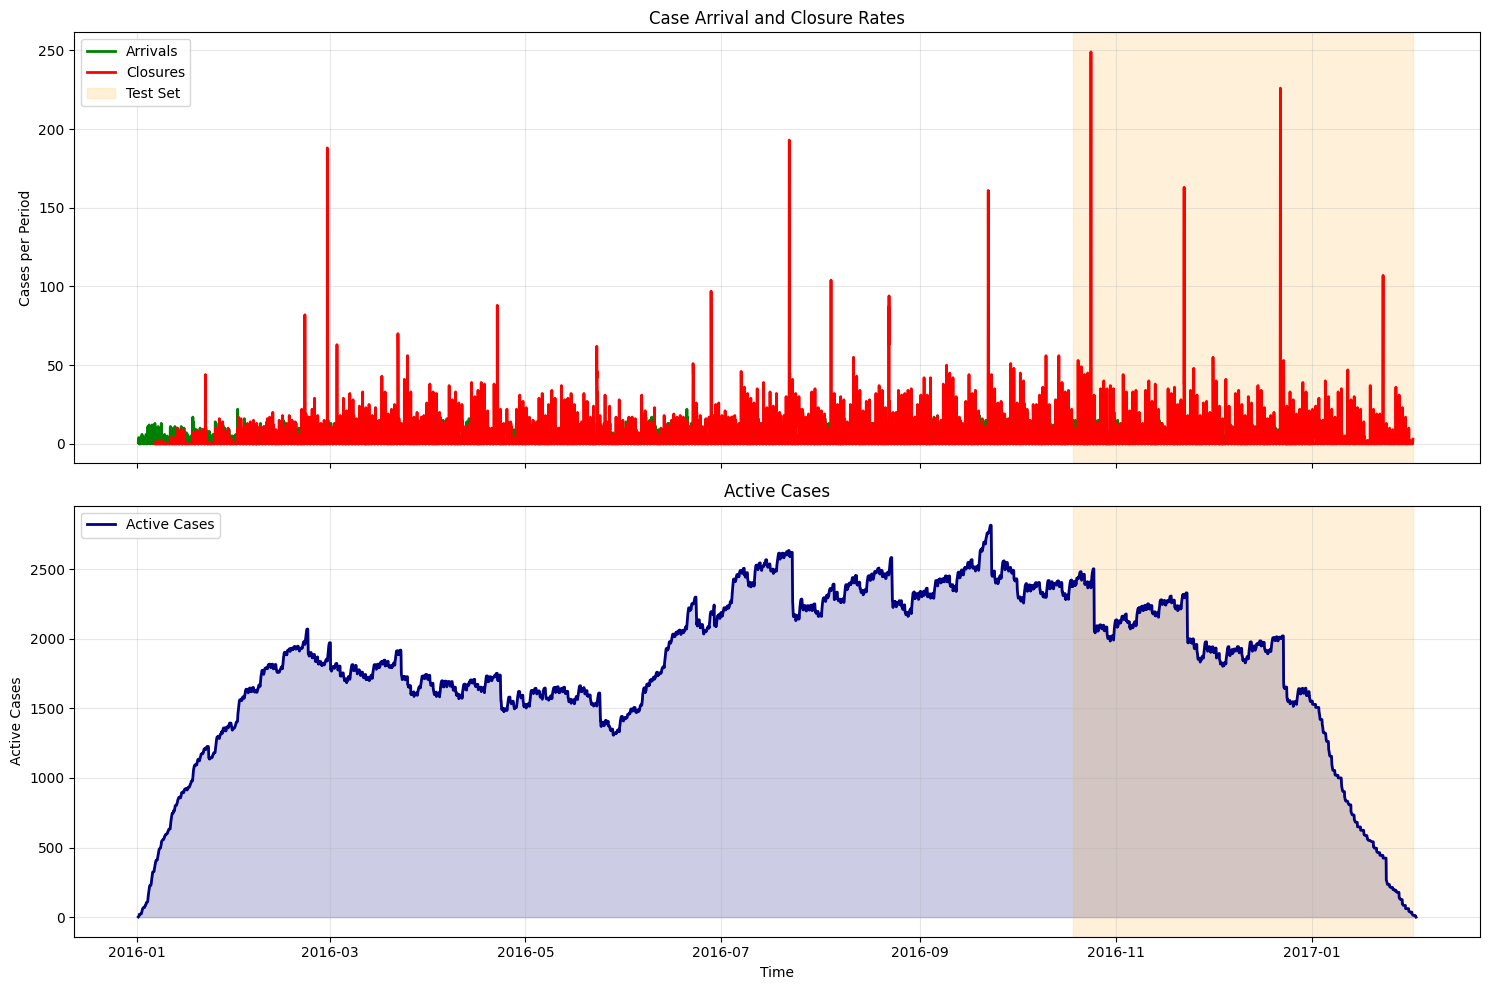

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

CASE_COL = "case:concept:name"
TIME_COL = "time:timestamp"
split_time = pd.Timestamp("2016-10-18 17:03:01")

df = dataset.log.copy()

# Ensure timestamps are datetime
df[TIME_COL] = pd.to_datetime(df[TIME_COL])

# Get start and end timestamp of each case
case_times = (
    df.groupby(CASE_COL)[TIME_COL]
      .agg(start_time="min", end_time="max")
      .reset_index()
)

# Aggregation granularity
freq = "1h"  # D=day, W=week, M=month

# ---------------------------------------------------
# Case arrivals
# ---------------------------------------------------

arrivals = (
    case_times
    .set_index("start_time")
    .resample(freq)
    .size()
)

# ---------------------------------------------------
# Case closures
# ---------------------------------------------------

closures = (
    case_times
    .set_index("end_time")
    .resample(freq)
    .size()
)

# ---------------------------------------------------
# Active cases
# ---------------------------------------------------

start_events = pd.Series(
    1,
    index=case_times["start_time"]
)

# Keep cases active through their completion bucket
end_events = pd.Series(
    -1,
    index=case_times["end_time"] + pd.Timedelta(days=1)
)

active_cases = (
    pd.concat([start_events, end_events])
      .sort_index()
      .resample(freq)
      .sum()
      .cumsum()
)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------

# ---------------------------------------------------
# Plot
# ---------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(15, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1]}
)

# Top subplot: arrivals and closures
ax1.plot(
    arrivals.index,
    arrivals.values,
    label="Arrivals",
    color="green",
    linewidth=2
)

ax1.plot(
    closures.index,
    closures.values,
    label="Closures",
    color="red",
    linewidth=2
)

# split line
ax1.axvspan(
    split_time,
    df["time:timestamp"].max(),
    color="orange",
    alpha=0.15,
    label="Test Set"
)


ax1.set_title("Case Arrival and Closure Rates")
ax1.set_ylabel("Cases per Period")
ax1.legend()
ax1.grid(alpha=0.3)

# Bottom subplot: active cases
ax2.plot(
    active_cases.index,
    active_cases.values,
    label="Active Cases",
    color="navy",
    linewidth=2
)

ax2.fill_between(
    active_cases.index,
    active_cases.values,
    alpha=0.2,
    color="navy"
)

ax2.axvspan(
    split_time,
    df["time:timestamp"].max(),
    color="orange",
    alpha=0.15
)

ax2.set_title("Active Cases")
ax2.set_xlabel("Time")
ax2.set_ylabel("Active Cases")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()